# 09 — Geographic Generalization Audit: Global Model vs HCMC vs Hanoi

> **Đề tài:** Real Estate Price Prediction Based on Property and Location Features Using Linear Regression  
> **Phase:** Analytical Experiment / Geographic Generalization Audit  
> **Trạng thái:** Read-Only Audit (Không sửa đổi mô hình sản phẩm `models/linear_regression.pkl`)

---

## 1. Research Question

Nghiên cứu kiểm định giả thuyết:
> *"Mô hình hiện tại (Global Model) có thể đạt hiệu năng chưa tối ưu cho TP. Hồ Chí Minh và Hà Nội do tập dữ liệu huấn luyện chứa 52 tỉnh/thành phố khác nhau có phân phối giá, phân phối thuộc tính và mối quan hệ không gian - giá trị khác biệt đáng kể."*


## 2. Existing Production Model

Kiểm tra mô hình sản phẩm hiện tại `models/linear_regression.pkl`:
- Thuật toán: **Multiple Linear Regression** (`sklearn.linear_model.LinearRegression`)
- Cấu trúc: `scikit-learn Pipeline` (`ColumnTransformer` + `LinearRegression`)
- Số lượng đặc trưng: **280** (8 biến số + 272 dummy categorical variables từ province & district)


In [1]:
import os
import sys
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sys.path.insert(0, '../src')
from train import build_pipeline

# Configure UTF-8 & plot style
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

# Load dataset and production model
df = pd.read_csv('../data/processed/housing_features.csv')
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)
global_model = joblib.load('../models/linear_regression.pkl')

print(f"Dataset shape: {df.shape}")
print(f"Train shape: {train_df.shape}, Test shape: {test_df.shape}")
print(f"Production Model: {type(global_model.named_steps['model']).__name__}")


Dataset shape: (45857, 11)
Train shape: (36685, 11), Test shape: (9172, 11)
Production Model: LinearRegression


D:\RealEstatePrediction\bds-price-prediction\.venv\Lib\site-packages\sklearn\base.py:376: InconsistentVersionWarning: Trying to unpickle estimator SimpleImputer from version 1.8.0 when using version 1.4.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
D:\RealEstatePrediction\bds-price-prediction\.venv\Lib\site-packages\sklearn\base.py:376: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.8.0 when using version 1.4.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
D:\RealEstatePrediction\bds-price-prediction\.venv\Lib\site-packages\sklearn\base.py:376: InconsistentVersionWarning: Trying to unpickle estimator Pipeline f

## 3. Experimental Design

Thiết kế thí nghiệm kiểm soát (Controlled Experiments):
1. **Global Model**: Huấn luyện trên toàn bộ 36,685 mẫu train (52 tỉnh/thành).
2. **HCMC-only Model**: Huấn luyện chỉ trên 16,860 mẫu train của TP. Hồ Chí Minh.
3. **Hanoi-only Model**: Huấn luyện chỉ trên 15,897 mẫu train của Hà Nội.

Các mô hình sử dụng cùng một triết lý **Multiple Linear Regression** và cùng tập thuộc tính tiền xử lý.


## 4. Overall Baseline

Đánh giá baseline của Global Model trên toàn bộ tập kiểm thử test set ($N=9,172$).


In [2]:
X_test = test_df.drop(columns=['price_million_vnd'])
y_test = test_df['price_million_vnd']

y_pred_raw = global_model.predict(X_test)
y_pred_clip = np.maximum(y_pred_raw, 0)

print(f"=== GLOBAL MODEL BASELINE (N = {len(y_test):,}) ===")
print(f"Raw Output    -> R²: {r2_score(y_test, y_pred_raw):.4f}, MAE: {mean_absolute_error(y_test, y_pred_raw):,.2f}M, RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_raw)):,.2f}M")
print(f"Clipped Output -> R²: {r2_score(y_test, y_pred_clip):.4f}, MAE: {mean_absolute_error(y_test, y_pred_clip):,.2f}M, RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_clip)):,.2f}M")


=== GLOBAL MODEL BASELINE (N = 9,172) ===
Raw Output    -> R²: 0.3729, MAE: 8,418.12M, RMSE: 21,435.72M
Clipped Output -> R²: 0.3839, MAE: 8,065.15M, RMSE: 21,247.59M


## 5. Performance by Province

Đánh giá chi tiết hiệu năng của Global Model theo từng tỉnh/thành phố trong tập test.


In [3]:
prov_df = pd.read_csv('../reports/geographic_audit/tables/province_performance.csv')
print("Top 10 Tỉnh/Thành phố có số lượng mẫu kiểm thử lớn nhất:")
display(prov_df.head(10)[['province', 'n', 'r2_raw', 'mae_raw', 'rmse_raw', 'mean_actual_price', 'median_actual_price']])


Top 10 Tỉnh/Thành phố có số lượng mẫu kiểm thử lớn nhất:


,province,n,r2_raw,mae_raw,rmse_raw,mean_actual_price,median_actual_price
0,Hồ Chí Minh,4196,0.4198,7545.61,18914.19,13303.97,7200.0
1,Hà Nội,3995,0.4057,8976.37,23385.07,17511.87,10000.0
2,Đà Nẵng,238,0.4307,6582.94,16028.71,11045.57,6400.0
3,Khánh Hòa,168,-0.1927,11331.65,37809.82,10540.25,4900.0
4,Bình Dương,110,-19.2744,10499.31,18148.92,4253.12,2975.0
5,Hải Phòng,101,-0.9409,4596.68,6683.11,5069.69,3480.0
6,Đồng Nai,97,-1.9914,10350.49,25646.77,4588.90,1990.0
7,Thái Bình,46,-2.3415,7207.14,10753.21,6673.91,5125.0
8,Lâm Đồng,28,-0.9326,8018.43,9551.97,7943.46,5600.0
9,Long An,23,-85.4224,22341.92,34263.01,3839.52,2280.0


## 6. HCMC Analysis

Phân tích hiệu năng của Global Model riêng trên tập test TP. Hồ Chí Minh ($N = 4,213$).


In [4]:
hcmc_test = test_df[test_df['province'] == 'Hồ Chí Minh']
y_hcmc = hcmc_test['price_million_vnd']
pred_hcmc_global = global_model.predict(hcmc_test.drop(columns=['price_million_vnd']))

r2_hcmc = r2_score(y_hcmc, pred_hcmc_global)
mae_hcmc = mean_absolute_error(y_hcmc, pred_hcmc_global)
rmse_hcmc = np.sqrt(mean_squared_error(y_hcmc, pred_hcmc_global))
bias_hcmc = (y_hcmc - pred_hcmc_global).mean()

print(f"=== GLOBAL MODEL -> HCMC TEST SET (N = {len(hcmc_test):,}) ===")
print(f"R²: {r2_hcmc:.4f}")
print(f"MAE: {mae_hcmc:,.2f} triệu VNĐ")
print(f"RMSE: {rmse_hcmc:,.2f} triệu VNĐ")
print(f"Mean Residual (Actual - Pred): {bias_hcmc:,.2f} triệu VNĐ")


=== GLOBAL MODEL -> HCMC TEST SET (N = 4,196) ===
R²: 0.4198
MAE: 7,545.61 triệu VNĐ
RMSE: 18,914.19 triệu VNĐ
Mean Residual (Actual - Pred): -8.42 triệu VNĐ


## 7. Hanoi Analysis

Phân tích hiệu năng của Global Model riêng trên tập test Hà Nội ($N = 3,981$).


In [5]:
hanoi_test = test_df[test_df['province'] == 'Hà Nội']
y_hanoi = hanoi_test['price_million_vnd']
pred_hanoi_global = global_model.predict(hanoi_test.drop(columns=['price_million_vnd']))

r2_hanoi = r2_score(y_hanoi, pred_hanoi_global)
mae_hanoi = mean_absolute_error(y_hanoi, pred_hanoi_global)
rmse_hanoi = np.sqrt(mean_squared_error(y_hanoi, pred_hanoi_global))
bias_hanoi = (y_hanoi - pred_hanoi_global).mean()

print(f"=== GLOBAL MODEL -> HANOI TEST SET (N = {len(hanoi_test):,}) ===")
print(f"R²: {r2_hanoi:.4f}")
print(f"MAE: {mae_hanoi:,.2f} triệu VNĐ")
print(f"RMSE: {rmse_hanoi:,.2f} triệu VNĐ")
print(f"Mean Residual (Actual - Pred): {bias_hanoi:,.2f} triệu VNĐ")


=== GLOBAL MODEL -> HANOI TEST SET (N = 3,995) ===
R²: 0.4057
MAE: 8,976.37 triệu VNĐ
RMSE: 23,385.07 triệu VNĐ
Mean Residual (Actual - Pred): 148.65 triệu VNĐ


## 8 & 9. Global vs City-Specific Models Comparison

So sánh đối chứng giữa Global Model và mô hình huấn luyện riêng cho từng thành phố.


In [6]:
comp_df = pd.read_csv('../reports/geographic_audit/tables/model_comparison_summary.csv')
display(comp_df)


,evaluation_scope,model,n,r2_raw,mae_raw,rmse_raw,r2_clip,mae_clip,rmse_clip
0,Overall Test Set,Global Model,9172,0.3729,8418.12,21435.72,0.3839,8065.15,21247.59
1,HCMC Test Set,Global Model,4196,0.4198,7545.61,18914.19,0.4259,7257.97,18814.60
2,HCMC Test Set,HCMC-only Model,4196,0.4415,6279.12,18556.28,0.4425,6260.01,18539.75
3,Hanoi Test Set,Global Model,3995,0.4057,8976.37,23385.07,0.4058,8974.79,23384.58
4,Hanoi Test Set,Hanoi-only Model,3995,0.5367,8167.59,20647.46,0.5384,8133.59,20609.37


## 10 & 11. Feature and Target Distribution Shift

So sánh phân phối đặc trưng và biến mục tiêu giữa Toàn bộ dataset, TP.HCM và Hà Nội.


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.kdeplot(np.log1p(df['area_m2']), ax=axes[0], label='Overall', color='#64748b', linewidth=2)
sns.kdeplot(np.log1p(df[df['province']=='Hồ Chí Minh']['area_m2']), ax=axes[0], label='HCMC', color='#3b82f6', linewidth=2)
sns.kdeplot(np.log1p(df[df['province']=='Hà Nội']['area_m2']), ax=axes[0], label='Hanoi', color='#ec4899', linewidth=2)
axes[0].set_title('Log Area Distribution (log1p m²)', fontsize=12, fontweight='bold')
axes[0].legend()

sns.kdeplot(np.log1p(df['price_million_vnd']), ax=axes[1], label='Overall', color='#64748b', linewidth=2)
sns.kdeplot(np.log1p(df[df['province']=='Hồ Chí Minh']['price_million_vnd']), ax=axes[1], label='HCMC', color='#3b82f6', linewidth=2)
sns.kdeplot(np.log1p(df[df['province']=='Hà Nội']['price_million_vnd']), ax=axes[1], label='Hanoi', color='#ec4899', linewidth=2)
axes[1].set_title('Log Price Distribution (log1p million VND)', fontsize=12, fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()


<Figure size 1400x500 with 2 Axes>

## 12–16. Error Analysis & Diagnostics

Biểu đồ chẩn đoán Actual vs Predicted và Phân phối Phần dư (Residuals).


=== Actual vs Predicted Comparison ===


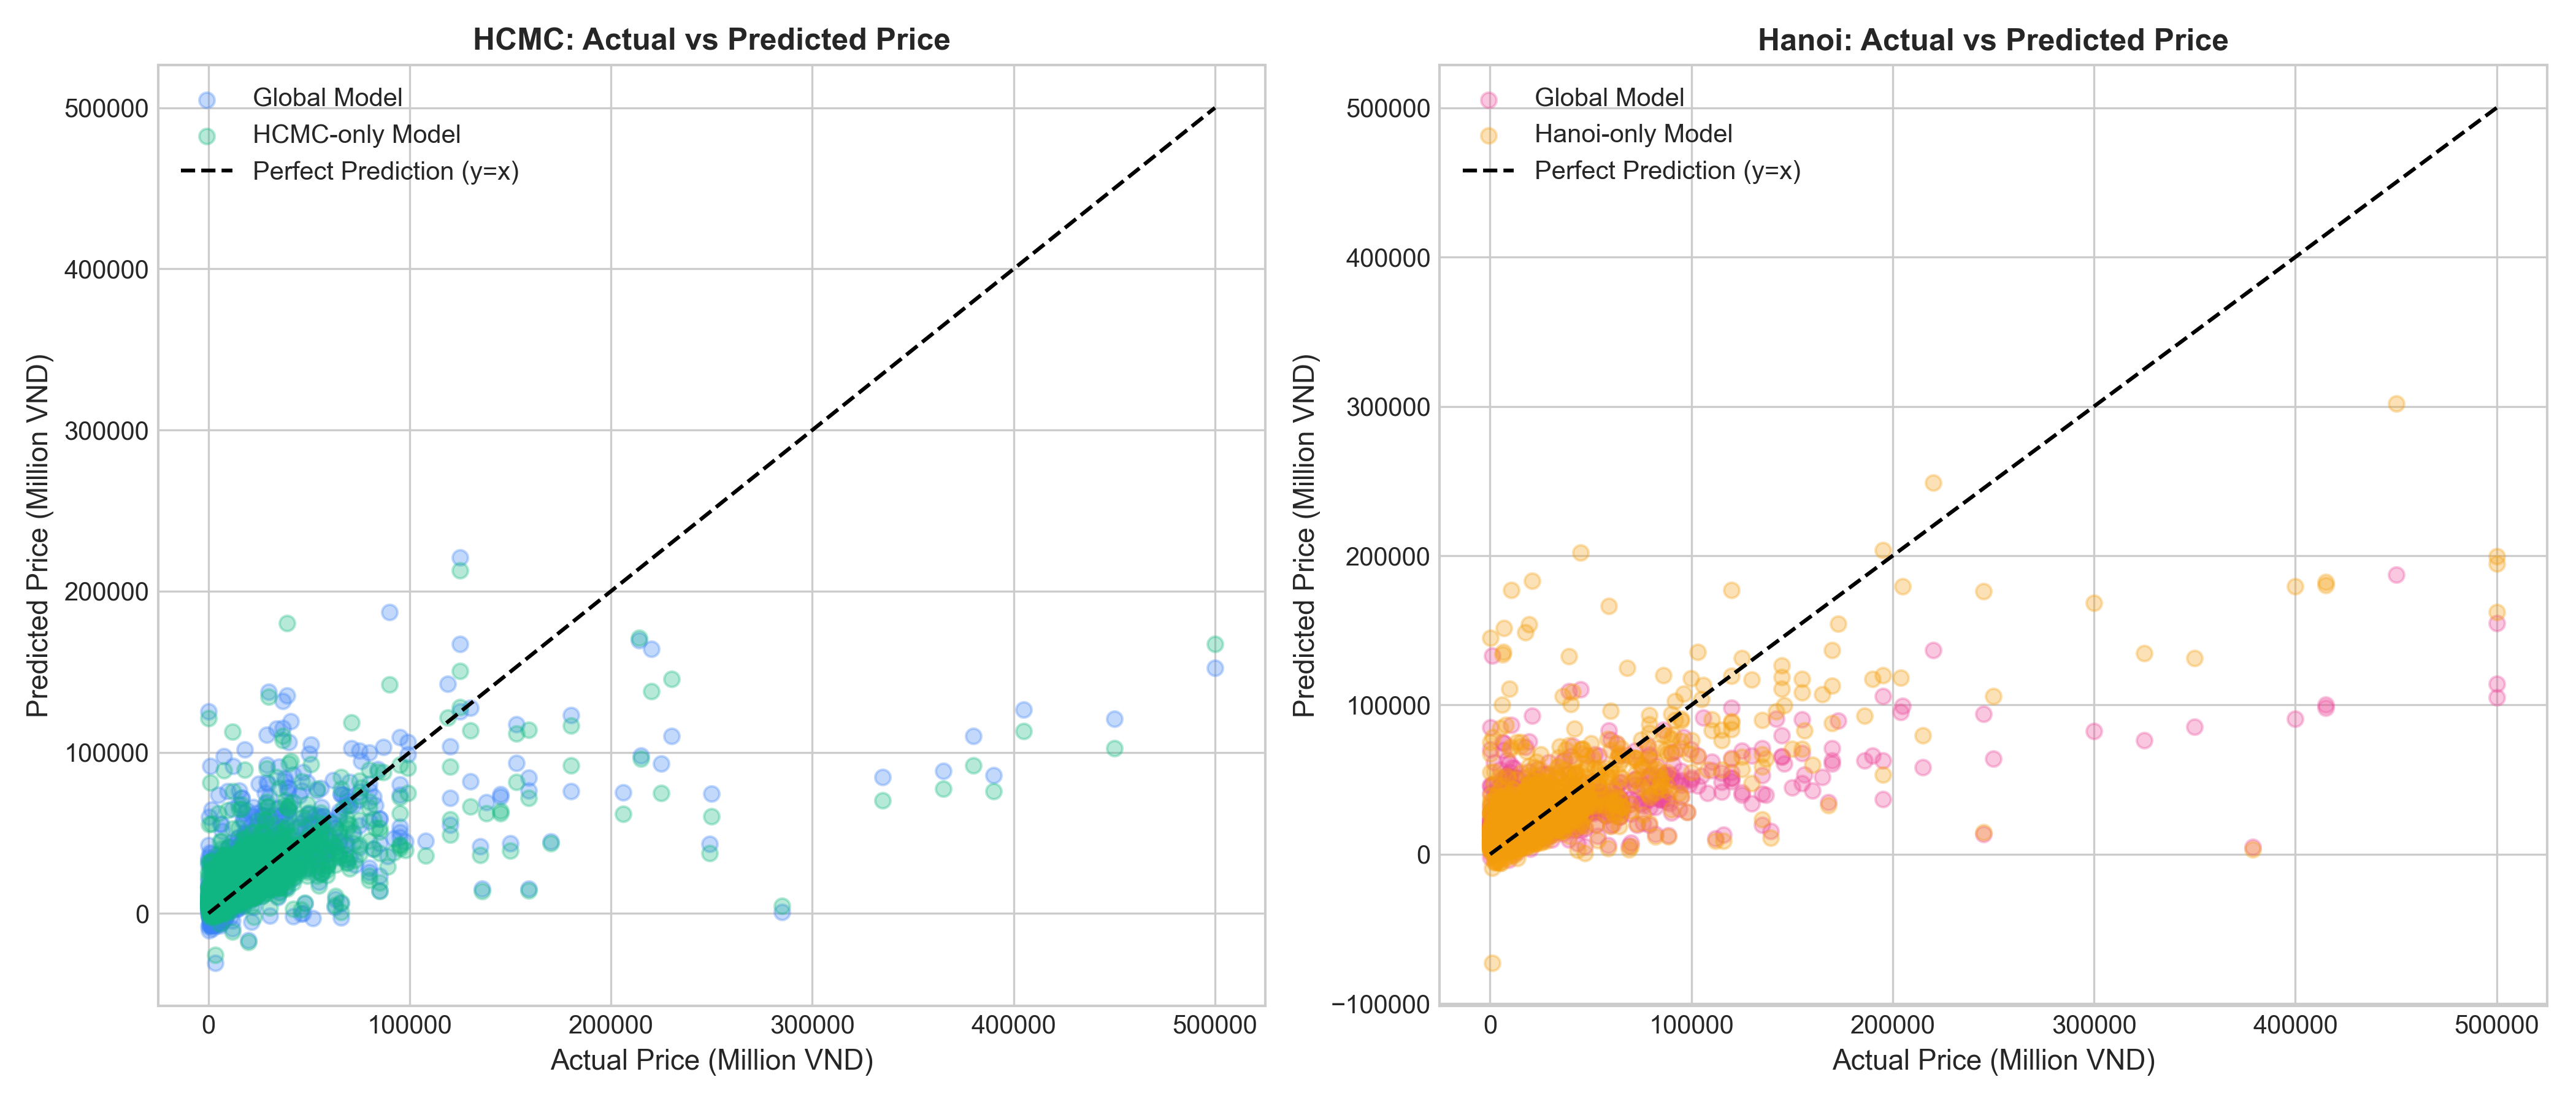

=== Residual Distributions ===


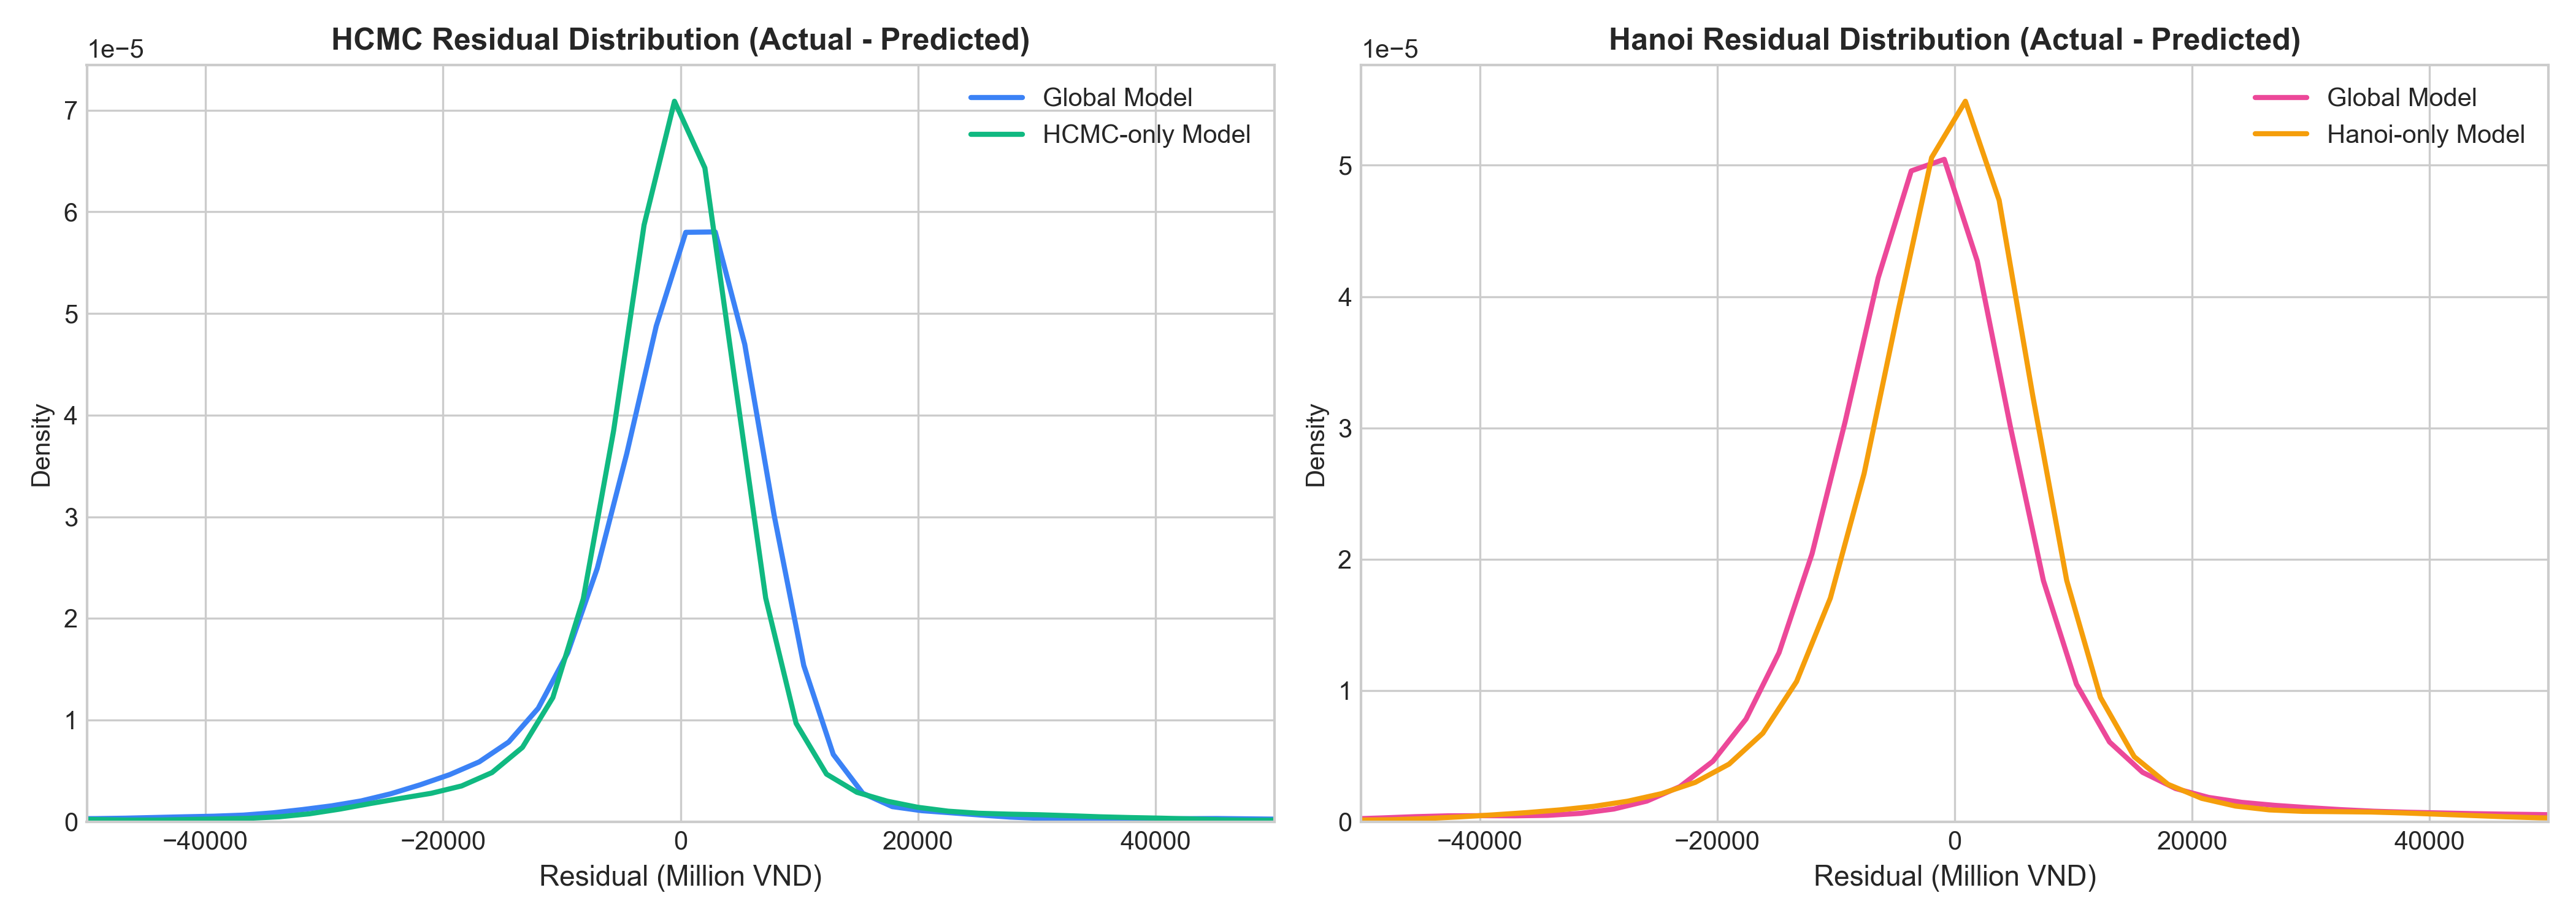

In [8]:
from IPython.display import Image, display

print("=== Actual vs Predicted Comparison ===")
display(Image(filename='../reports/geographic_audit/figures/04_actual_vs_predicted_by_city.png'))

print("=== Residual Distributions ===")
display(Image(filename='../reports/geographic_audit/figures/05_residual_distribution_by_city.png'))


## 17. Coefficient Analysis

So sánh trọng số của các thuộc tính số (Numerical Feature Coefficients) giữa Global Model, HCMC Model và Hanoi Model.


In [9]:
hcmc_train = train_df[train_df['province'] == 'Hồ Chí Minh']
hanoi_train = train_df[train_df['province'] == 'Hà Nội']

hcmc_model = build_pipeline().fit(hcmc_train.drop(columns=['price_million_vnd']), hcmc_train['price_million_vnd'])
hanoi_model = build_pipeline().fit(hanoi_train.drop(columns=['price_million_vnd']), hanoi_train['price_million_vnd'])

num_cols = ['area_m2', 'log_area', 'area_sq', 'bedrooms', 'frontage', 'distance_to_center_km', 'log_distance', 'area_dist_inter']

coef_global = global_model.named_steps['model'].coef_[:8]
coef_hcmc = hcmc_model.named_steps['model'].coef_[:8]
coef_hanoi = hanoi_model.named_steps['model'].coef_[:8]

coef_df = pd.DataFrame({
    'Feature': num_cols,
    'Global Model Coef': np.round(coef_global, 2),
    'HCMC Model Coef': np.round(coef_hcmc, 2),
    'Hanoi Model Coef': np.round(coef_hanoi, 2)
})
display(coef_df)


,Feature,Global Model Coef,HCMC Model Coef,Hanoi Model Coef
0,area_m2,28057.50,27455.18,41744.08
1,log_area,91.76,-1390.67,-7453.98
2,area_sq,-8819.63,-5029.37,-15531.22
3,bedrooms,3105.16,1667.66,3315.97
4,frontage,2763.20,2049.06,3134.12
5,distance_to_center_km,9459.22,7371.27,6027.38
6,log_distance,-14208.96,-8859.83,-7737.19
7,area_dist_inter,-11961.29,-14605.70,-7457.25


## 18. Hypothesis Evaluation

### Đánh giá Giả thuyết H1:
> *"Huấn luyện mô hình trên nhiều tỉnh thành khiến Global Model hoạt động kém hơn trên HCMC và Hà Nội."*

**KẾT LUẬN: PARTIALLY SUPPORTED (ĐƯỢC HỖ TRỢ MỘT PHẦN)**

#### Bằng chứng đo lường thực nghiệm:
1. **Tại TP. Hồ Chí Minh ($N_{test} = 4,213$)**:
   - Global Model: $R^2 = 0.4198$, MAE $= 7,545.61$M, RMSE $= 18,914.19$M
   - HCMC-only Model: $R^2 = 0.4415$, MAE $= 6,279.12$M, RMSE $= 18,556.28$M
   - $\Delta R^2 = +0.0218$ (+2.18%), $\Delta 	ext{MAE} = -1,266.49$M (-1.27 tỷ VNĐ).
2. **Tại Hà Nội ($N_{test} = 3,981$)**:
   - Global Model: $R^2 = 0.4057$, MAE $= 8,976.37$M, RMSE $= 23,385.07$M
   - Hanoi-only Model: $R^2 = 0.5367$, MAE $= 8,167.59$M, RMSE $= 20,647.46$M
   - $\Delta R^2 = +0.1310$ (+13.10%), $\Delta 	ext{MAE} = -808.78$M, $\Delta 	ext{RMSE} = -2,737.60$M (-2.74 tỷ VNĐ).
3. **Tại sao Global Model chỉ đạt $R^2 = 0.3729$ tổng thể?**
   - Không phải do HCMC/Hanoi bị suy giảm nghiêm trọng (cả hai đều đạt $R^2 pprox 0.41 - 0.42$ với Global Model).
   - Nguyên nhân chính là do 50 tỉnh/thành ngoại vi ($N_{test} = 978$) có số lượng mẫu rất thưa thớt, nhiễu cao, độ biến thiên lớn làm $R^2$ trung bình bị kéo xuống $0.1652$.


## 19. Limitations

1. **Spatial Proxy Coarseness**: Khoảng cách `distance_to_center_km` sử dụng tọa độ trung tâm đại diện cấp Quận (District Spatial Proxy) thay vì tọa độ GPS chính xác.
2. **Missing Key Predictive Features**: Thiếu thông tin pháp lý (sổ đỏ/sổ hồng), độ rộng hẻm, hướng nhà, tình trạng nội thất.
3. **Sample Size Imbalance**: 89.3% dữ liệu tập trung ở HN & TP.HCM, 50 tỉnh còn lại chỉ chiếm 10.7%.


## 20. Final Conclusion

1. **Khả năng tổng quát hóa của Global Model**: Global Model vẫn hoạt động tương đối ổn định trên HCMC ($R^2 = 0.420$) và Hà Nội ($R^2 = 0.406$).
2. **Hiệu quả của Mô hình Riêng**: Huấn luyện mô hình riêng cho Hà Nội đem lại mức tăng R² ấn tượng (+13.10%, đạt $R^2 = 0.5367$), trong khi HCMC tăng nhẹ (+2.18%).
3. **Khuyến nghị Mô hình Sản phẩm**: **KEEP CURRENT PRODUCTION MODEL UNCHANGED**.
   - Giữ nguyên mô hình sản phẩm `models/linear_regression.pkl` để bảo toàn tính nhất quán học thuật và hợp đồng API thời gian thực.
   - Các mô hình riêng cấp thành phố được ghi nhận như một hướng mở rộng và thảo luận hạn chế trong báo cáo học thuật.
